In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #below is for to display inline graph 
%matplotlib inline 

**Loading House pricing dataset**

In [31]:
bengaluru = pd.read_csv("Bengaluru_House_Data.csv")

In [32]:
bengaluru.keys()

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [36]:
#Lets check description of the dataset which are import using sklearn lib
#print(california.DESCR)

In [38]:
#print(california.data)

In [39]:
#print(bengaluru.target) # here target means the price of the house

**Preparing the Dataset**

In [42]:
dataset = pd.DataFrame(bengaluru)

In [43]:
dataset

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [ ]:
# to add the target in the dataset
#dataset["Price"] = california.target

In [44]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [45]:
dataset.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [46]:
#check the missing values
dataset.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [48]:
#handling missing values
dataset["location"].fillna(dataset["location"].mode()[0],inplace=True)

In [50]:
dataset["size"].fillna(dataset["size"].mode()[0],inplace=True)

In [52]:
dataset = dataset.drop(["society"],axis=1)

In [53]:
dataset['balcony'].fillna(dataset['balcony'].median(), inplace=True)

C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_1760\3086510303.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['balcony'].fillna(dataset['balcony'].median(), inplace=True)


In [57]:
dataset['bath'].fillna(dataset["bath"].mode()[0],inplace=True)

C:\Users\Utkarsh\AppData\Local\Temp\ipykernel_1760\2606528158.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['bath'].fillna(dataset["bath"].mode()[0],inplace=True)


In [87]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataset["area_type"] = le.fit_transform(dataset['area_type'])
dataset['availability'] = le.fit_transform(dataset["availability"])
dataset['size'] = le.fit_transform(dataset["size"])
dataset['location'] = le.fit_transform(dataset["location"])

In [88]:
dataset

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,3,37,213,5,1056,2.0,1.0,39.07
1,2,76,151,10,2600,5.0,3.0,120.00
3,3,76,393,7,1521,3.0,1.0,95.00
5,3,76,639,5,1170,2.0,1.0,38.00
6,3,31,461,9,2732,4.0,2.0,204.00
...,...,...,...,...,...,...,...,...
13313,3,76,603,7,1345,2.0,1.0,57.00
13314,3,76,238,7,1715,3.0,3.0,112.00
13315,0,76,639,12,3453,4.0,0.0,231.00
13317,0,76,499,5,1141,2.0,1.0,60.00


In [89]:
dataset.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [90]:
#EDA
##Correlation is imp related regression
dataset.corr(numeric_only=True)

,area_type,availability,location,size,bath,balcony,price
area_type,1.000000,-0.123390,0.055942,-0.063555,-0.022893,0.016157,-0.035152
availability,-0.123390,1.000000,0.008556,0.059046,0.000869,0.174693,0.004950
location,0.055942,0.008556,1.000000,0.035550,0.064019,0.029425,0.071899
size,-0.063555,0.059046,0.035550,1.000000,0.753494,0.315274,0.496358
bath,-0.022893,0.000869,0.064019,0.753494,1.000000,0.268017,0.583908
balcony,0.016157,0.174693,0.029425,0.315274,0.268017,1.000000,0.168353
price,-0.035152,0.004950,0.071899,0.496358,0.583908,0.168353,1.000000


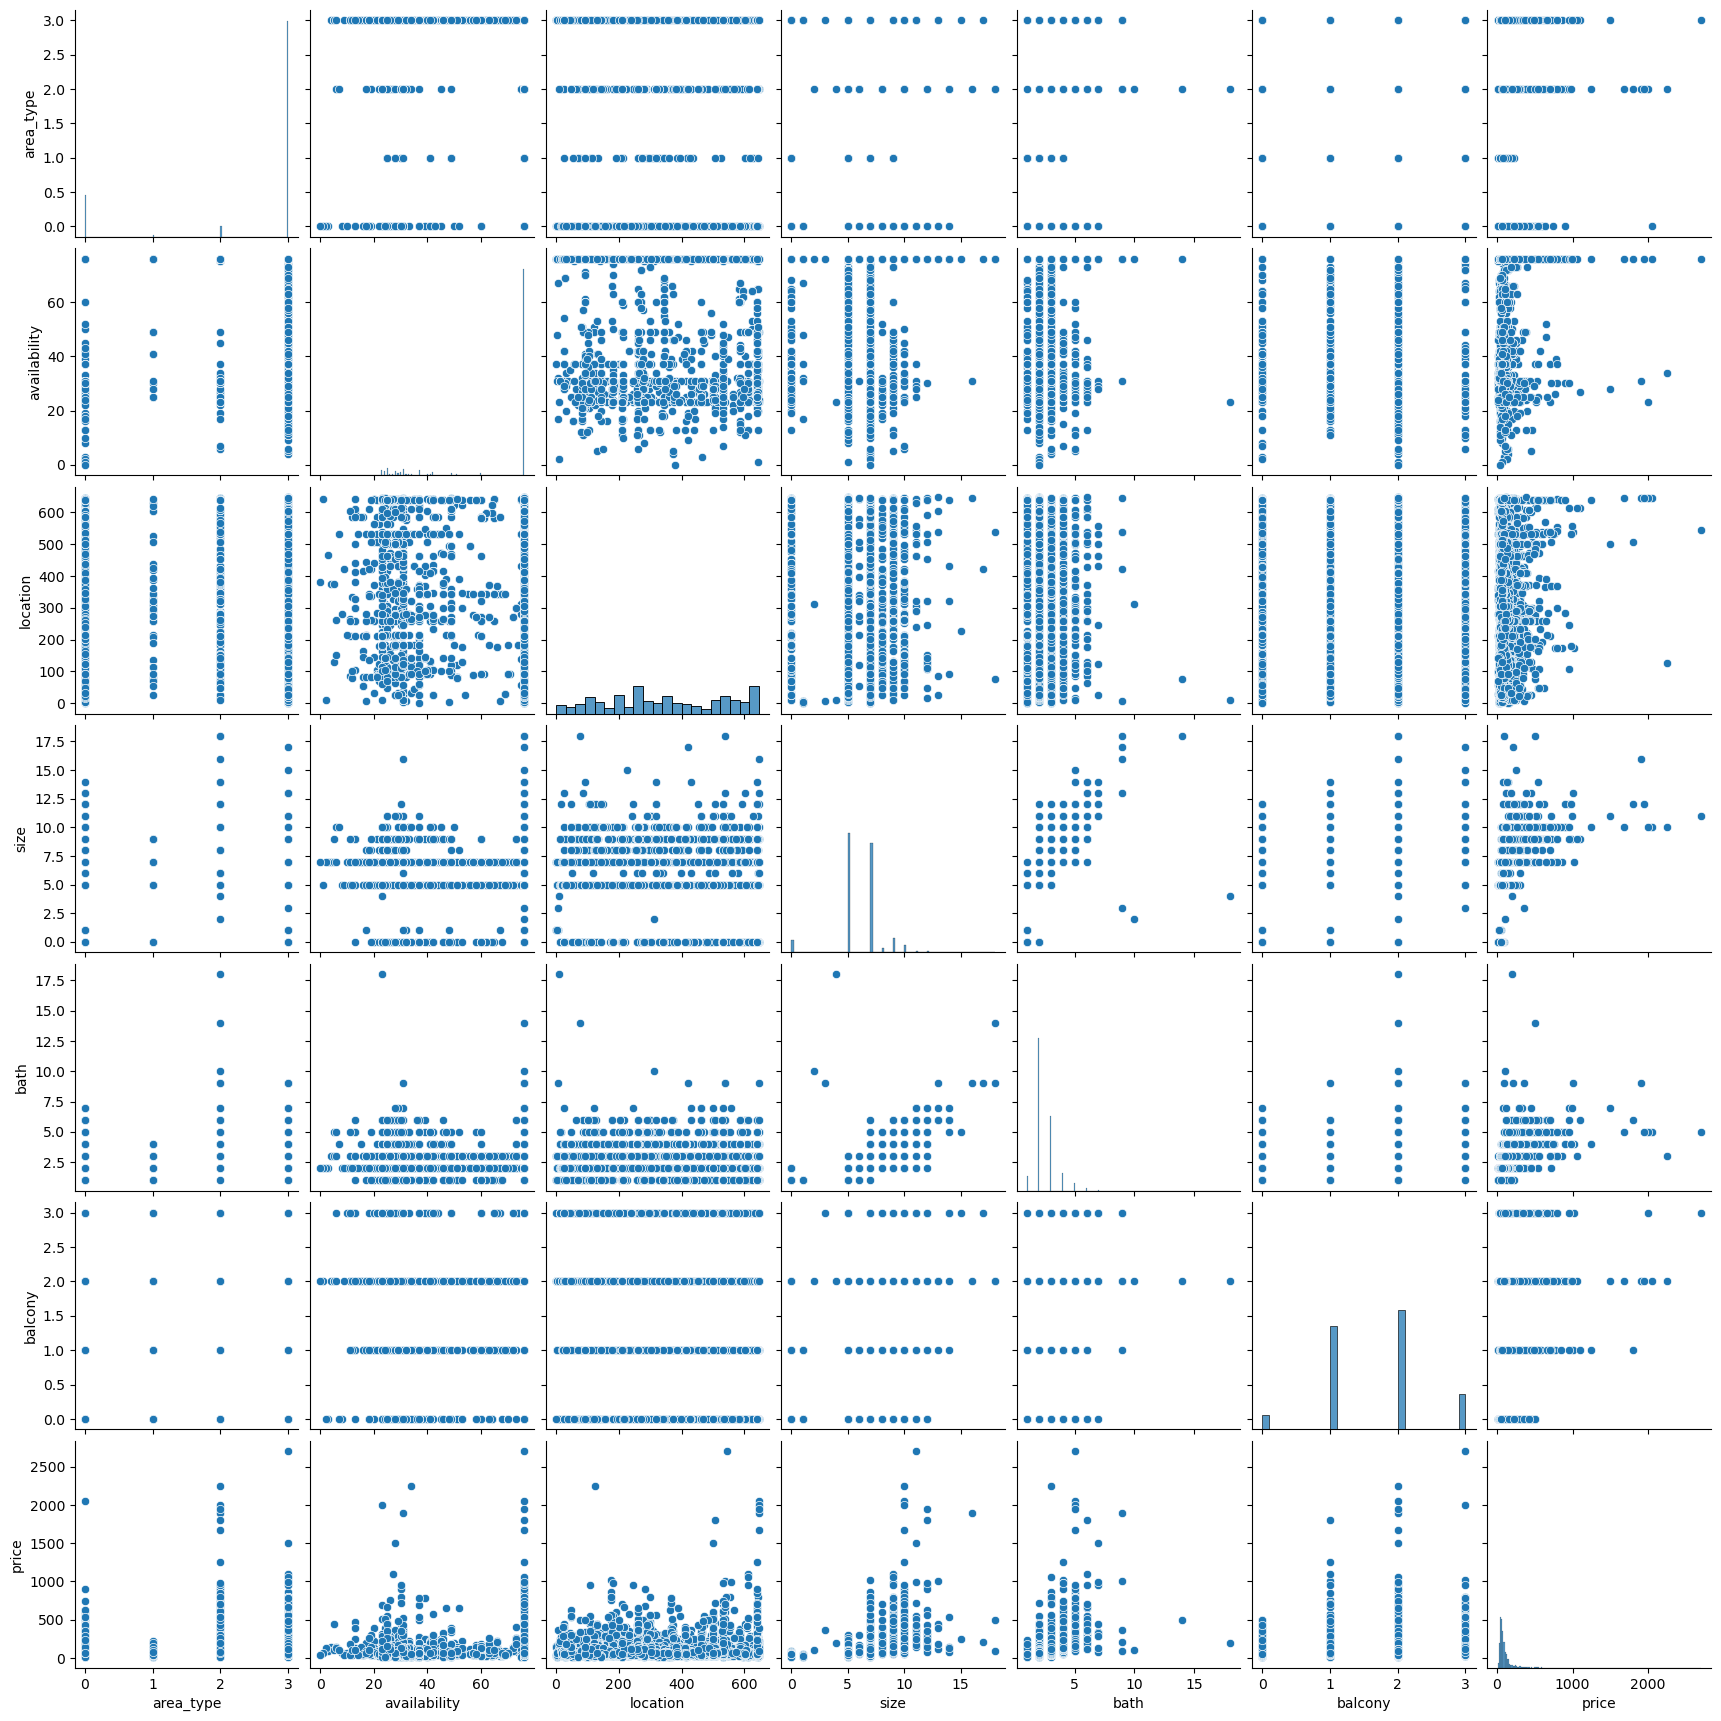

In [91]:
import seaborn as sns
sns.pairplot(dataset)

Text(0, 0.5, 'price')

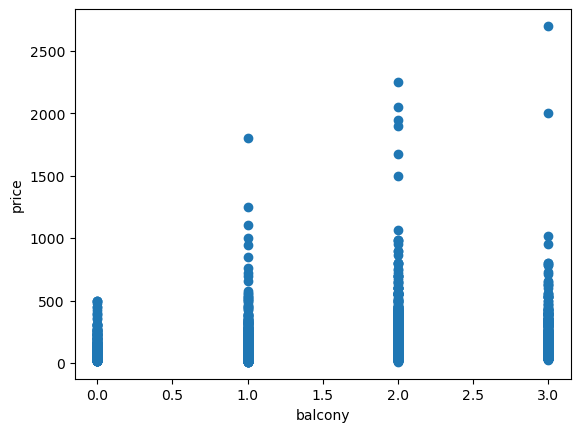

In [92]:
plt.scatter(dataset['balcony'],dataset['price'])
plt.xlabel("balcony")
plt.ylabel("price")

<Axes: xlabel='size', ylabel='price'>

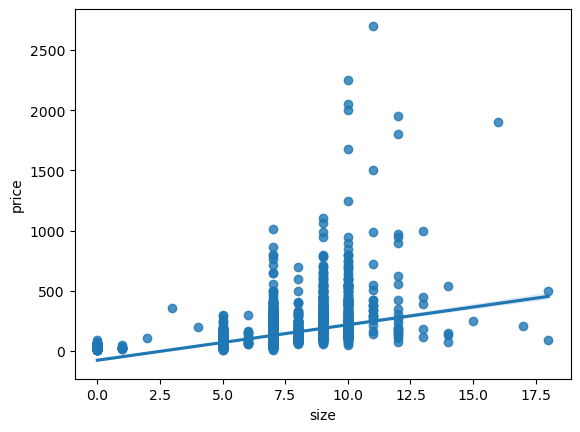

In [93]:
sns.regplot(x= "size",y = "price",data=dataset)

In [94]:
# independent and dependent features
x = dataset.iloc[:,:-1] #independent
y = dataset.iloc[:,-1] #dependent

In [95]:
x.head()

,area_type,availability,location,size,total_sqft,bath,balcony
0,3,37,213,5,1056,2.0,1.0
1,2,76,151,10,2600,5.0,3.0
3,3,76,393,7,1521,3.0,1.0
5,3,76,639,5,1170,2.0,1.0
6,3,31,461,9,2732,4.0,2.0


In [96]:
y.head()

0     39.07
1    120.00
3     95.00
5     38.00
6    204.00
Name: price, dtype: float64

In [97]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train, y_test = train_test_split(x,y,test_size=0.38, random_state=42)

In [98]:
#standardizing the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [102]:
x_train = x_train.select_dtypes(include=['int64','float64'])

In [105]:
x_test = x_test.reindex(columns=x_train.columns,fill_value=0)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [103]:
x_train = scaler.fit_transform(x_train) #fit to scale the train data

In [104]:
x_test =- scaler.transform(x_test) # x_test should not know about the training data

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- total_sqft
